# 무한매수법 백테스트

패키지 API(`run_backtest`)로 등록 전략 `infinite_buy`를 실행하는 러너입니다. 로직 소스는 `src/backtest/strategies/infinite_buy.py`입니다.

**커널:** Cursor에서 프로젝트 `.venv`를 고르거나, `uv sync --group notebook` 후 `uv run jupyter lab`.

**데이터 전제:** `data/market-data/curated/daily_prices/`가 있어야 합니다. 없으면:

```bash
uv run market-data backfill --start 2015-01-01
```

사이클 시작 시 한 번 정하는 값: `splits`, `initial_cash`, `big_buy_pct`, `target_pct`. 보유수량·평단은 체결로 매일 갱신됩니다. 가정은 [토이 백테스트](/docs/backtest.md)를 보세요.

투자 조언을 제공하지 않습니다.

In [181]:
from backtest import (
    available_strategies,
    format_infinite_buy_report,
    infinite_buy_fills,
    plot_backtest,
    run_backtest,
    style_infinite_buy_equity,
    style_infinite_buy_fills,
    summarize_infinite_buy,
)

available_strategies()

['golden_cross', 'infinite_buy']

In [182]:
from datetime import date
from pathlib import Path

security_id = "KRX:024060"
strategy = "infinite_buy"
data_dir = Path("data/market-data")
start = date(2023, 1, 1)
end = date(2026, 8, 17)
splits = 50
target_pct = 0.12
big_buy_pct = 0.12
initial_cash = 10_000_000.0
fee_rate = 0.00009  # 편도 위탁수수료. 0.00009 = 0.009%
sell_tax_rate = 0.002  # 코스닥 매도세 0.20%. 매수에는 없음
wait_extended = False  # True면 N일 고점 근처에서 사이클 재시작을 쉼
# wait_extended = True
# entry_lookback = 20
# entry_pullback_pct = 0.10

In [183]:
result = run_backtest(
    strategy,
    security_id,
    data_dir=data_dir,
    start=start,
    end=end,
    initial_cash=initial_cash,
    fee_rate=fee_rate,
    sell_tax_rate=sell_tax_rate,
    splits=splits,
    target_pct=target_pct,
    big_buy_pct=big_buy_pct,
    wait_extended=wait_extended,
)
print(format_infinite_buy_report(summarize_infinite_buy(result)))

상태: 진행 중 (기간 끝) · 22사이클 완료
평가 수익률 +62.85%   투입액 대비 +34.90%
손익 +6,285,114
10,000,000 → 16,285,114
재투자 +8,010,631   최종 사이클 원금 18,010,631
최대 투입액 18,008,880 (180%)
수수료 -34,902   세금 -386,544

사이클 22   2023-01-02 ~ 2026-08-11
경과 1317일 / 거래일 880일
MDD -34.54%   평단 회복 162거래일   물밀 합계 678거래일
매수 2097 / 매도 137
MDD 구간: 2026-04-13 ~ 2026-07-07
가장 긴 물밀: 2024-10-10 ~ 2025-06-11

단순보유 5,520 → 19,474,638  (+94.75%)
알파 -3,189,524


In [184]:
style_infinite_buy_equity(result.equity.head(10))

,일자,모드,T,보유수량,평단,별지점,별%,시가,고가,저가,종가,잔금,원금,투입,평가금,평가손익
0,2023-01-02,일반,1.0000,36,"5,520","6,156",11.52%,"5,620","5,750","5,520","5,520","9,801,262","10,000,000","198,720","9,999,982",-17.88
1,2023-01-03,일반,2.0000,72,"5,495","6,102",11.04%,"5,420","5,540","5,220","5,470","9,604,324","10,000,000","395,640","9,998,164","-1,835.61"
2,2023-01-04,일반,2.5000,88,"5,498","6,091",10.80%,"5,400","5,560","5,320","5,510","9,516,156","10,000,000","483,800","10,001,036","+1,036.46"
3,2023-01-05,일반,3.0000,104,"5,498","6,079",10.56%,"5,520","5,580","5,490","5,500","9,428,149","10,000,000","571,800","10,000,149",+148.54
4,2023-01-06,일반,3.5000,120,"5,509","6,078",10.32%,"5,460","5,580","5,460","5,580","9,338,861","10,000,000","661,080","10,008,461","+8,460.50"
5,2023-01-09,일반,4.0000,136,"5,521","6,077",10.08%,"5,590","5,630","5,580","5,610","9,249,092","10,000,000","750,840","10,012,052","+12,052.42"
6,2023-01-10,일반,4.5000,152,"5,536","6,080",9.84%,"5,610","5,720","5,610","5,660","9,158,524","10,000,000","841,400","10,018,844","+18,844.27"
7,2023-01-11,일반,5.0000,168,"5,553","6,086",9.60%,"5,650","5,720","5,650","5,720","9,066,996","10,000,000","932,920","10,027,956","+27,956.04"
8,2023-01-12,일반,5.5000,184,"5,568","6,090",9.36%,"5,760","5,760","5,670","5,730","8,975,308","10,000,000","1,024,600","10,029,628","+29,627.79"
9,2023-01-13,일반,6.0000,200,"5,585","6,095",9.12%,"5,810","5,870","5,770","5,780","8,882,819","10,000,000","1,117,080","10,038,819","+38,819.46"


In [185]:
fills = infinite_buy_fills(result)
print(f"체결 이력 ({len(fills)}건 · 투입 = 보유 매입원가(수수료 제외) · 평가손익 = 평가금-원금 · 가로선 = 사이클 완료)")
style_infinite_buy_fills(fills.head(30))

체결 이력 (2234건 · 투입 = 보유 매입원가(수수료 제외) · 평가손익 = 평가금-원금 · 가로선 = 사이클 완료)


,일자,구분,종류,수량,누적수량,체결가,금액,수수료,세금,투입(누적),평가손익
0,2023-01-02,매수,처음매수,32,32,"5,520","176,640",15.90,0.00,"176,640",-15.90
1,2023-01-02,매수,보조계단,1,33,"5,520","5,520",0.50,0.00,"182,160",-16.39
2,2023-01-02,매수,보조계단,1,34,"5,520","5,520",0.50,0.00,"187,680",-16.89
3,2023-01-02,매수,보조계단,1,35,"5,520","5,520",0.50,0.00,"193,200",-17.39
4,2023-01-02,매수,보조계단,1,36,"5,520","5,520",0.50,0.00,"198,720",-17.88
5,2023-01-03,매수,별지점 절반,16,52,"5,470","87,520",7.88,0.00,"286,240","-1,825.76"
6,2023-01-03,매수,평단 절반,20,72,"5,470","109,400",9.85,0.00,"395,640","-1,835.61"
7,2023-01-04,매수,별지점 절반,16,88,"5,510","88,160",7.93,0.00,"483,800","+1,036.46"
8,2023-01-05,매수,별지점 절반,16,104,"5,500","88,000",7.92,0.00,"571,800",+148.54
9,2023-01-06,매수,별지점 절반,16,120,"5,580","89,280",8.04,0.00,"661,080","+8,460.50"


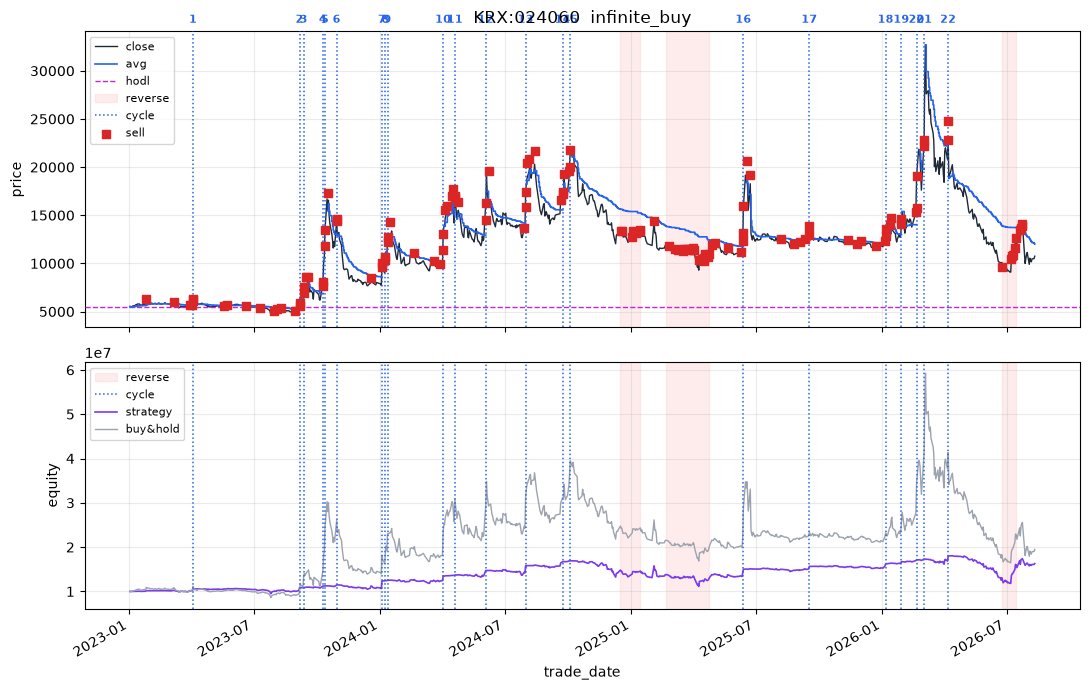

In [186]:
plot_backtest(result, security_id=security_id, strategy=strategy, fast=None, slow=None, show=True)